In [ ]:
pip install torch torchvision opencv-python numpy matplotlib Pillow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
EPS = 1e-7

def vertical_diameter(binary_segmentation):
    '''Get the vertical diameter from a binary segmentation.'''
    # Ensure binary_segmentation is at least 2D
    if binary_segmentation.ndim < 2:
        binary_segmentation = binary_segmentation[:, np.newaxis]  # Add a new axis if it's 1D

    vertical_axis_diameter = np.sum(binary_segmentation, axis=1)
    # Now, vertical_axis_diameter will have at least one dimension
    diameter = np.max(vertical_axis_diameter)  # Find max without specifying axis if it's 1D
    return diameter

def vertical_cup_to_disc_ratio(od, oc):
    '''Compute the vertical cup-to-disc ratio from a given labelling map.'''
    cup_diameter = vertical_diameter(oc)
    disc_diameter = vertical_diameter(od)
    return cup_diameter / (disc_diameter + EPS)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.0.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


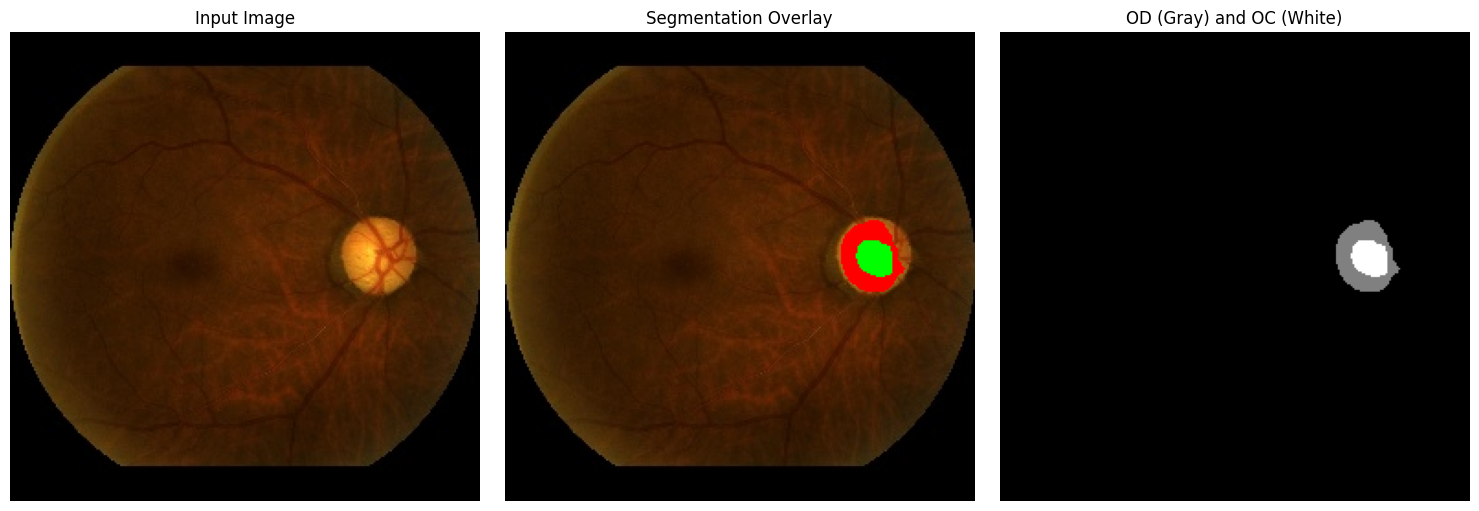

Diagnosis: Glaucoma (Confidence: 98.19%)


In [ ]:
import torch
import os
import pickle
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import cv2
from google.colab import drive
import torch.nn as nn
import torch.nn.functional as F
import torch


#MODEL ARCHITECTURE
class DoubleConv(torch.nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(mid_channels),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(torch.nn.Module):
    def __init__(self, n_channels=3, n_classes=2):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor)
        self.up2 = Up(512, 256 // factor)
        self.up3 = Up(256, 128 // factor)
        self.up4 = Up(128, 64)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return torch.sigmoid(logits)

class Down(torch.nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = torch.nn.Sequential(
            torch.nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(torch.nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Use the normal convolutions to reduce the number of channels
        self.up = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)


    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(torch.nn.Module):
    '''
    Simple convolution.
    '''
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = torch.nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

#HELPER FUNCTIONS
def process_image(image_path, output_size=(256, 256)):
    """Preprocess image for inference"""
    img = Image.open(image_path).convert('RGB')  # Ensure RGB format

    # Resize before converting to NumPy array
    img = img.resize(output_size, Image.BILINEAR)

    # Convert to tensor
    img_tensor = transforms.functional.to_tensor(img)

    return img_tensor


def refine_seg(mask):
    """Clean up small artifacts in segmentation"""
    mask = mask.numpy().astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    return torch.from_numpy(cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel))

#LOAD MODELS
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load segmentation model
unet_model = UNet(n_channels=3, n_classes=2).to(device)

# Load state dictionary
state_dict = torch.load('/content/drive/MyDrive/Glaucoma/Model/glaucoma_segmentation_v0.1.pth', map_location=device)

# Fix state_dict key mismatch
for key in list(state_dict.keys()):
    if "output_layer" in key:
        new_key = key.replace("output_layer", "outc")
        state_dict[new_key] = state_dict.pop(key)

# Load updated state dict
unet_model.load_state_dict(state_dict, strict=False)
unet_model.eval()

# Load classifier model
with open('/content/drive/MyDrive/Glaucoma/Model/glaucoma_classifier_v0.1.pkl', 'rb') as f:
    clf_model = pickle.load(f)

#INFERENCE FUNCTION
def predict_glaucoma(image_path, visualize=True):
    """Run full glaucoma detection pipeline"""
    img_tensor = process_image(image_path).to(device).unsqueeze(0)  # Ensure correct shape

    # Segmentation
    with torch.no_grad():
        logits = unet_model(img_tensor)

    # Post-process masks
    pred_od = refine_seg((logits[:,0,:,:] >= 0.5).cpu()).to(device)
    pred_oc = refine_seg((logits[:,1,:,:] >= 0.5).cpu()).to(device)

    # Calculate vCDR
    vCDR = vertical_cup_to_disc_ratio(
        pred_oc[0].cpu().numpy(),
        pred_od[0].cpu().numpy()
    )

    # Classify glaucoma
    proba = clf_model.predict_proba(np.array([[vCDR]]))[0,1]
    pred_label = "Glaucoma" if proba > 0.5 else "Normal"

    # Visualization
    if visualize:
        plt.figure(figsize=(15,5))

        # Input image
        plt.subplot(1,3,1)
        plt.imshow(img_tensor.cpu().squeeze(0).permute(1,2,0))
        plt.title("Input Image")
        plt.axis('off')

        # Overlay
        plt.subplot(1,3,2)
        overlay = img_tensor.cpu().squeeze(0).permute(1,2,0).numpy().copy()
        overlay[pred_od[0].cpu().numpy() > 0.5] = [1, 0, 0]  # Red for OD
        overlay[pred_oc[0].cpu().numpy() > 0.5] = [0, 1, 0]  # Green for OC
        plt.imshow(overlay)
        plt.title("Segmentation Overlay")
        plt.axis('off')

        # Masks
        plt.subplot(1,3,3)
        combined_mask = np.zeros_like(pred_od[0].cpu().numpy(), dtype=np.uint8)
        combined_mask[pred_od[0].cpu().numpy() > 0.5] = 128
        combined_mask[pred_oc[0].cpu().numpy() > 0.5] = 255
        plt.imshow(combined_mask, cmap='gray')
        plt.title("OD (Gray) and OC (White)")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    return {
        "vCDR": vCDR,
        "diagnosis": pred_label,
        "confidence": proba,
        "od_mask": pred_od[0].cpu().numpy(),
        "oc_mask": pred_oc[0].cpu().numpy()
    }

#RUN INFERENCE
image_path = '/content/drive/MyDrive/Glaucoma/RG/EyePACS-Glaucoma-2803.jpg'
result = predict_glaucoma(image_path)

print(f"Diagnosis: {result['diagnosis']} (Confidence: {result['confidence']:.2%})")


In [ ]:
for name, param in unet_model.named_parameters():
    print(f"{name}: {param.shape}")


inc.double_conv.0.weight: torch.Size([64, 3, 3, 3])
inc.double_conv.0.bias: torch.Size([64])
inc.double_conv.1.weight: torch.Size([64])
inc.double_conv.1.bias: torch.Size([64])
inc.double_conv.3.weight: torch.Size([64, 64, 3, 3])
inc.double_conv.3.bias: torch.Size([64])
inc.double_conv.4.weight: torch.Size([64])
inc.double_conv.4.bias: torch.Size([64])
down1.maxpool_conv.1.double_conv.0.weight: torch.Size([128, 64, 3, 3])
down1.maxpool_conv.1.double_conv.0.bias: torch.Size([128])
down1.maxpool_conv.1.double_conv.1.weight: torch.Size([128])
down1.maxpool_conv.1.double_conv.1.bias: torch.Size([128])
down1.maxpool_conv.1.double_conv.3.weight: torch.Size([128, 128, 3, 3])
down1.maxpool_conv.1.double_conv.3.bias: torch.Size([128])
down1.maxpool_conv.1.double_conv.4.weight: torch.Size([128])
down1.maxpool_conv.1.double_conv.4.bias: torch.Size([128])
down2.maxpool_conv.1.double_conv.0.weight: torch.Size([256, 128, 3, 3])
down2.maxpool_conv.1.double_conv.0.bias: torch.Size([256])
down2.maxpool

Full Batch Processing Code

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

# Set directories
normal_dir = "/content/drive/MyDrive/Glaucoma/NRG"
glaucoma_dir = "/content/drive/MyDrive/Glaucoma/RG"
resized_dir = "/content/drive/MyDrive/Glaucoma/Resized_Images"  # New folder for resized images
output_csv = "/content/drive/MyDrive/Glaucoma/OCOD_results.csv"
output_img_dir = "/content/drive/MyDrive/Glaucoma/OCOD_Results"

# Create output directories if they don't exist
os.makedirs(resized_dir + "/Normal", exist_ok=True)
os.makedirs(resized_dir + "/Glaucoma", exist_ok=True)
os.makedirs(output_img_dir + "Normal", exist_ok=True)
os.makedirs(output_img_dir + "Glaucoma", exist_ok=True)

# Initialize results list
results = []

# Function to resize and save images
def resize_and_save(image_path, save_path, output_size=(256, 256)):
    """Resize image and save to new directory."""
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize(output_size, Image.BILINEAR)
        img.save(save_path)
        return save_path  # Return the path of the resized image
    except Exception as e:
        print(f"Skipping {image_path}: {e}")
        return None

# Process all images
for label, folder in [("Normal", normal_dir), ("Glaucoma", glaucoma_dir)]:
    for image_name in tqdm(os.listdir(folder), desc=f"Processing {label} images"):
        image_path = os.path.join(folder, image_name)
        resized_path = os.path.join(resized_dir, label, image_name)  # New resized image path

        # Resize and save image
        resized_image_path = resize_and_save(image_path, resized_path)
        if resized_image_path is None:
            continue  # Skip if image couldn't be resized

        try:
            # Run prediction on resized image
            result = predict_glaucoma(resized_image_path, visualize=False)

            # Save segmentation overlay
            plt.figure(figsize=(6,6))
            overlay = np.array(Image.open(resized_image_path).convert("RGB"))
            overlay[result["od_mask"] > 0.5] = [255, 0, 0]  # Red for OD
            overlay[result["oc_mask"] > 0.5] = [0, 255, 0]  # Green for OC
            plt.imshow(overlay)
            plt.axis("off")

            # Save processed image
            save_path = os.path.join(output_img_dir, label, image_name)
            plt.savefig(save_path, bbox_inches='tight')
            plt.close()

            # Append results
            results.append({
                "image_name": image_name,
                "truth_label": label,
                "predicted_label": result["diagnosis"],
                "vCDR": result["vCDR"],
                "confidence": result["confidence"]
            })

        except Exception as e:
            print(f"Error processing {image_name}: {e}")

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"\nResults saved to: {output_csv}")


Processing Normal images:   0%|          | 0/515 [00:00<?, ?it/s]

Error processing EyePACS-NRG-2790.jpg: name 'predict_glaucoma' is not defined
Error processing EyePACS-NRG-2784.jpg: name 'predict_glaucoma' is not defined
Error processing EyePACS-NRG-2778.jpg: name 'predict_glaucoma' is not defined
Error processing EyePACS-NRG-2785.jpg: name 'predict_glaucoma' is not defined
Error processing EyePACS-NRG-2792.jpg: name 'predict_glaucoma' is not defined


Processing Normal images:   1%|          | 6/515 [00:00<01:24,  6.02it/s]

Error processing EyePACS-NRG-2772.jpg: name 'predict_glaucoma' is not defined


Processing Normal images:   1%|▏         | 7/515 [00:01<02:12,  3.83it/s]

...

Error processing EyePACS-Glaucoma-3265.jpg: name 'predict_glaucoma' is not defined


Processing Glaucoma images: 100%|█████████▉| 509/510 [08:01<00:00,  1.24it/s]

Error processing EyePACS-Glaucoma-3269.jpg: name 'predict_glaucoma' is not defined


Processing Glaucoma images: 100%|██████████| 510/510 [08:02<00:00,  1.06it/s]

Error processing EyePACS-Glaucoma-3267.jpg: name 'predict_glaucoma' is not defined

Results saved to: /content/drive/MyDrive/Glaucoma/OCOD_results.csv


 Performance Metrics Calculation

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Load results CSV
csv_path = "/content/drive/MyDrive/Glaucoma/results.csv"
df = pd.read_csv(csv_path)

# Map labels to binary (1 = Glaucoma, 0 = Normal)
df["truth_label"] = df["truth_label"].map({"Glaucoma": 1, "Normal": 0})
df["predicted_label"] = df["predicted_label"].map({"Glaucoma": 1, "Normal": 0})

# Extract true labels, predictions, and probabilities
y_true = df["truth_label"].values
y_pred = df["predicted_label"].values
y_proba = df["confidence"].values  # Probability scores

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=1)
recall = recall_score(y_true, y_pred, zero_division=1)
f1 = f1_score(y_true, y_pred, zero_division=1)
auc_roc = roc_auc_score(y_true, y_proba)
conf_matrix = confusion_matrix(y_true, y_pred)

# Prepare results as text
metrics_text = f"""
**Model Performance Metrics**
Accuracy: {accuracy:.2%}
Precision: {precision:.2%}
Recall: {recall:.2%}
F1-Score: {f1:.2%}
AUC-ROC: {auc_roc:.2%}
Confusion Matrix:
{conf_matrix}
"""

# Save results to a text file in Google Drive
metrics_file = "/content/drive/MyDrive/Glaucoma/performance_metrics.txt"
with open(metrics_file, "w") as f:
    f.write(metrics_text)

print(f"\nPerformance metrics saved to: {metrics_file}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your CSV file
csv_path = "/content/drive/MyDrive/Glaucoma/results.csv"

# Load CSV file
df = pd.read_csv(csv_path)

# Select only the first 10 rows
df = df.head(20)

# Extract relevant data
image_names = df["image_name"].tolist()  # First 10 Image names
cdr_values = df["vCDR"].tolist()  # First 10 CDR values

# Define thresholds
normal_threshold = 0.3
glaucoma_threshold = 0.6

# Assign colors based on CDR values
bar_colors = ["green" if cdr < normal_threshold else "yellow" if cdr < glaucoma_threshold else "red" for cdr in cdr_values]

# Plot Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(image_names, cdr_values, color=bar_colors)

# Add threshold lines
plt.axhline(y=normal_threshold, color='green', linestyle='--', label="Normal CDR (≤0.3)")
plt.axhline(y=glaucoma_threshold, color='red', linestyle='--', label="Glaucoma Risk (≥0.6)")

# Labels & Title
plt.xlabel("Image ID")
plt.ylabel("Cup-to-Disc Ratio (CDR)")
plt.title("CDR Values from First 10 Fundus Images")
plt.xticks(rotation=45)  # Rotate x-axis labels slightly for readability
plt.legend()
plt.ylim(0, 1)  # Set y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show Plot
plt.show()
